# Event labels, full-trial epochs, and time-frequency EEG

This notebook demonstrates trial-level preprocessing on **A10 Run 3**, an online motor-imagery recording. A10 was selected because:

- its `COMMENTS` field is empty in `Perfomances_cleaned.csv`;
- it does not appear in the repository validation-issues report;
- it is not among the paper's seven participants flagged for problematic neurophysiology (A4, A9, A17, A29, A41, B78, B79); and
- it is not among the other documented missing/configuration exceptions (A1, A9, A11, A40, A59, C83).

Every annotation in the GDF is returned in `event_df`. Trials are constructed from the actual trial-start marker (`768`) through the actual end-of-trial marker (`800`), with labels supplied by cue `769` (left hand) or `770` (right hand). The complete eight-second EEG interval is retained for each trial. EOG and EMG sensors are excluded because they are not EEG electrodes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display

mne.set_log_level('ERROR')

def find_project_data(start=Path.cwd()):
    for parent in (start.resolve(), *start.resolve().parents):
        candidate = parent / 'data' / 'processed' / 'Signals'
        if candidate.is_dir():
            return parent / 'data'
    raise FileNotFoundError('Could not locate data/processed/Signals.')

DATA_ROOT = find_project_data()
PARTICIPANT = 'A10'
GDF_PATH = DATA_ROOT / 'processed' / 'Signals' / 'DATA A' / PARTICIPANT / 'A10_R3_onlineT.gdf'
PERFORMANCE_PATH = DATA_ROOT / 'processed' / 'Perfomances_cleaned.csv'
ISSUES_PATH = DATA_ROOT.parent / 'results' / 'reports' / 'validation_issues.csv'
OUTPUT_ROOT = DATA_ROOT / 'processed' / 'trial_time_frequency' / PARTICIPANT
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

PAPER_NEUROPHYSIOLOGY_FLAGS = {'A4', 'A9', 'A17', 'A29', 'A41', 'B78', 'B79'}
OTHER_DOCUMENTED_EXCEPTIONS = {'A1', 'A9', 'A11', 'A40', 'A59', 'C83'}
assert PARTICIPANT not in PAPER_NEUROPHYSIOLOGY_FLAGS | OTHER_DOCUMENTED_EXCEPTIONS
assert GDF_PATH.is_file(), GDF_PATH

performance = pd.read_csv(PERFORMANCE_PATH, sep=';')
participant_row = performance.loc[performance['SUJ_ID'].eq(PARTICIPANT)]
assert len(participant_row) == 1
comment = participant_row['COMMENTS'].iloc[0]
assert pd.isna(comment) or not str(comment).strip(), f'{PARTICIPANT} has a comment: {comment}'

issues = pd.read_csv(ISSUES_PATH)
participant_issues = issues.loc[
    issues['participant_run'].fillna('').str.match(rf'^{PARTICIPANT}(?:/|$)')
]
assert participant_issues.empty, f'{PARTICIPANT} appears in validation issues.'

print(f'Selected file: {GDF_PATH}')
print('Selection checks passed: no comment, validation issue, or documented participant flag.')

Selected file: /Users/aninanni/Documents/cosmos/26-the-data-miners-analysis/bci_cleaning/data/processed/Signals/DATA A/A10/A10_R3_onlineT.gdf
Selection checks passed: no comment, validation issue, or documented participant flag.


## Locate every event label

Descriptions below follow the dataset documentation. Codes `1010`, `33281`, and any unexpected code are retained but explicitly marked as undocumented rather than assigned a guessed meaning.

In [2]:
raw = mne.io.read_raw_gdf(GDF_PATH, preload=False, verbose='ERROR')
events, event_id = mne.events_from_annotations(raw, verbose=False)
id_to_code = {internal_id: str(code) for code, internal_id in event_id.items()}

EVENT_DESCRIPTIONS = {
    '32769': 'run_start',
    '32770': 'run_end',
    '768': 'trial_start',
    '786': 'fixation_cross',
    '33282': 'acoustic_signal',
    '769': 'left_hand_cue',
    '770': 'right_hand_cue',
    '781': 'feedback_start',
    '800': 'feedback_and_trial_end',
    '1010': 'undocumented_1010',
    '33281': 'undocumented_33281',
}

event_codes = [id_to_code[event] for event in events[:, 2]]
event_df = pd.DataFrame({
    'event_number': np.arange(1, len(events) + 1),
    'sample': events[:, 0],
    'onset_seconds': events[:, 0] / raw.info['sfreq'],
    'gdf_code': event_codes,
    'event_label': [EVENT_DESCRIPTIONS.get(code, f'undocumented_{code}') for code in event_codes],
    'mne_internal_id': events[:, 2],
})

event_df.to_csv(OUTPUT_ROOT / 'A10_R3_all_events.csv', index=False)
print(f'{len(event_df)} events found at {raw.info["sfreq"]:g} Hz.')
display(event_df)

event_counts = (
    event_df.groupby(['gdf_code', 'event_label'], sort=False)
    .size().rename('count').reset_index()
)
display(event_counts)

244 events found at 512 Hz.


,event_number,sample,onset_seconds,gdf_code,event_label,mne_internal_id
0,1,0,0.00,32769,run_start,2
1,2,2560,5.00,768,trial_start,6
2,3,2560,5.00,786,fixation_cross,10
3,4,3584,7.00,33282,acoustic_signal,5
4,5,4096,8.00,770,right_hand_cue,8
...,...,...,...,...,...,...
239,240,222336,434.25,781,feedback_start,9
240,241,224256,438.00,800,feedback_and_trial_end,11
241,242,225280,440.00,1010,undocumented_1010,1
242,243,227840,445.00,33281,undocumented_33281,4


,gdf_code,event_label,count
0,32769,run_start,1
1,768,trial_start,40
2,786,fixation_cross,40
3,33282,acoustic_signal,40
4,770,right_hand_cue,20
5,781,feedback_start,40
6,800,feedback_and_trial_end,40
7,769,left_hand_cue,20
8,1010,undocumented_1010,1
9,33281,undocumented_33281,1


## Pair event markers into complete trials

No fixed duration is assumed here. Each start is paired with the first subsequent end marker, and the cue inside that interval supplies the class. The resulting assertions deliberately stop execution if a trial is missing a cue/end, contains multiple class cues, or differs in length.

In [3]:
trial_records = []
start_rows = event_df.index[event_df['gdf_code'].eq('768')].tolist()

for trial_number, start_row in enumerate(start_rows, start=1):
    start_sample = int(event_df.at[start_row, 'sample'])
    next_start_sample = (
        int(event_df.at[start_rows[trial_number], 'sample'])
        if trial_number < len(start_rows) else np.inf
    )
    within_trial = event_df.loc[
        event_df['sample'].ge(start_sample) & event_df['sample'].lt(next_start_sample)
    ]
    ends = within_trial.loc[within_trial['gdf_code'].eq('800')]
    cues = within_trial.loc[within_trial['gdf_code'].isin(['769', '770'])]
    if len(ends) != 1 or len(cues) != 1:
        raise ValueError(
            f'Trial {trial_number}: expected one cue and one end; found {len(cues)} cue(s), {len(ends)} end(s).'
        )

    end_sample = int(ends.iloc[0]['sample'])
    cue_sample = int(cues.iloc[0]['sample'])
    cue_code = str(cues.iloc[0]['gdf_code'])
    trial_records.append({
        'trial': trial_number,
        'start_sample': start_sample,
        'cue_sample': cue_sample,
        'end_sample': end_sample,
        'start_seconds': start_sample / raw.info['sfreq'],
        'cue_seconds': cue_sample / raw.info['sfreq'],
        'end_seconds': end_sample / raw.info['sfreq'],
        'cue_offset_seconds': (cue_sample - start_sample) / raw.info['sfreq'],
        'duration_seconds': (end_sample - start_sample) / raw.info['sfreq'],
        'gdf_cue_code': cue_code,
        'class_label': 'left' if cue_code == '769' else 'right',
    })

trial_df = pd.DataFrame(trial_records)
trial_df.to_csv(OUTPUT_ROOT / 'A10_R3_trials.csv', index=False)

assert len(trial_df) == 40
assert trial_df['class_label'].value_counts().to_dict() == {'left': 20, 'right': 20}
assert trial_df['duration_seconds'].nunique() == 1
assert trial_df['cue_offset_seconds'].nunique() == 1

display(trial_df)
display(trial_df.groupby('class_label').agg(trials=('trial', 'size'), mean_duration=('duration_seconds', 'mean')))
print(f'All trials are {trial_df["duration_seconds"].iloc[0]:g} seconds long; cue occurs at +{trial_df["cue_offset_seconds"].iloc[0]:g} seconds.')

,trial,start_sample,cue_sample,end_sample,start_seconds,cue_seconds,end_seconds,cue_offset_seconds,duration_seconds,gdf_cue_code,class_label
0,1,2560,4096,6656,5.0,8.0,13.0,3.0,8.0,770,right
1,2,7680,9216,11776,15.0,18.0,23.0,3.0,8.0,769,left
2,3,13312,14848,17408,26.0,29.0,34.0,3.0,8.0,770,right
3,4,18432,19968,22528,36.0,39.0,44.0,3.0,8.0,770,right
4,5,24576,26112,28672,48.0,51.0,56.0,3.0,8.0,770,right
5,6,30208,31744,34304,59.0,62.0,67.0,3.0,8.0,770,right
6,7,35840,37376,39936,70.0,73.0,78.0,3.0,8.0,770,right
7,8,41472,43008,45568,81.0,84.0,89.0,3.0,8.0,770,right
8,9,47616,49152,51712,93.0,96.0,101.0,3.0,8.0,770,right
9,10,53760,55296,57856,105.0,108.0,113.0,3.0,8.0,769,left


,trials,mean_duration
class_label,,
left,20,8.0
right,20,8.0


All trials are 8 seconds long; cue occurs at +3 seconds.


## Extract the entire EEG trial as an epoch

The 27 scalp electrodes are retained. The five EOG/EMG sensors are excluded. A 1–40 Hz filter removes slow drift and frequencies outside the analysis range before extracting every sample from trial start up to (but not including) the end marker.

In [4]:
NON_EEG_CHANNELS = {'EOG1', 'EOG2', 'EOG3', 'EMGg', 'EMGd'}
eeg_channels = [channel for channel in raw.ch_names if channel not in NON_EEG_CHANNELS]
assert len(eeg_channels) == 27, f'Expected 27 EEG electrodes, found {len(eeg_channels)}.'

raw.load_data(verbose='ERROR')
raw.filter(1.0, 40.0, picks=eeg_channels, method='fir', phase='zero', verbose='ERROR')

sample_lengths = (trial_df['end_sample'] - trial_df['start_sample']).to_numpy()
assert np.unique(sample_lengths).size == 1
samples_per_trial = int(sample_lengths[0])

epoch_data = np.stack([
    raw.get_data(
        picks=eeg_channels,
        start=int(row.start_sample),
        stop=int(row.end_sample),
    )
    for row in trial_df.itertuples(index=False)
])

cue_offset = float(trial_df['cue_offset_seconds'].iloc[0])
epoch_times = np.arange(samples_per_trial) / raw.info['sfreq'] - cue_offset
class_labels = trial_df['class_label'].to_numpy()
class_ids = np.where(class_labels == 'left', 0, 1)

print('epoch_data shape:', epoch_data.shape, '= trials × electrodes × time samples')
print(f'Time relative to cue: {epoch_times[0]:.3f} to {epoch_times[-1]:.3f} seconds')
print('EEG electrodes:', eeg_channels)

epoch_data shape: (40, 27, 4096) = trials × electrodes × time samples
Time relative to cue: -3.000 to 4.998 seconds
EEG electrodes: ['Fz', 'FCz', 'Cz', 'CPz', 'Pz', 'C1', 'C3', 'C5', 'C2', 'C4', 'C6', 'F4', 'FC2', 'FC4', 'FC6', 'CP2', 'CP4', 'CP6', 'P4', 'F3', 'FC1', 'FC3', 'FC5', 'CP1', 'CP3', 'CP5', 'P3']


## Morlet time-frequency transform

The transform retains 8–30 Hz in 1 Hz steps. A half-second Morlet window is used at every frequency (`n_cycles = frequency / 2`). Output is decimated only along the time axis after transformation to reduce memory. Power is converted to µV² and then expressed as decibels relative to the pre-cue interval from −3 to −1 seconds (the first two seconds of the trial, before the acoustic signal).

In [5]:
frequencies_hz = np.arange(8.0, 31.0, 1.0)
n_cycles = frequencies_hz / 2.0
DECIMATION = 8

power_v2 = mne.time_frequency.tfr_array_morlet(
    epoch_data,
    sfreq=raw.info['sfreq'],
    freqs=frequencies_hz,
    n_cycles=n_cycles,
    output='power',
    decim=DECIMATION,
    zero_mean=True,
    n_jobs=1,
    verbose=False,
)
power_uv2 = power_v2 * 1e12
tfr_times = epoch_times[::DECIMATION]

baseline_mask = (tfr_times >= -3.0) & (tfr_times < -1.0)
baseline_power = power_uv2[..., baseline_mask].mean(axis=-1, keepdims=True)
tiny = np.finfo(power_uv2.dtype).tiny
ersp_db = 10.0 * np.log10(np.maximum(power_uv2, tiny) / np.maximum(baseline_power, tiny))

print('ersp_db shape:', ersp_db.shape, '= trials × electrodes × frequencies × time points')
print(f'Frequency range: {frequencies_hz[0]:g}–{frequencies_hz[-1]:g} Hz')
print(f'Output time resolution: {np.diff(tfr_times).mean():.5f} seconds')
print('Finite values:', np.isfinite(ersp_db).all())

ersp_db shape: (40, 27, 23, 512) = trials × electrodes × frequencies × time points
Frequency range: 8–30 Hz
Output time resolution: 0.01562 seconds
Finite values: True


## Inspect class-average time-frequency patterns at C3 and C4

Blue represents reduced power relative to the pre-cue baseline (ERD); red represents increased power (ERS). The vertical dashed line is cue onset and the dotted line is feedback onset at +1.25 seconds.

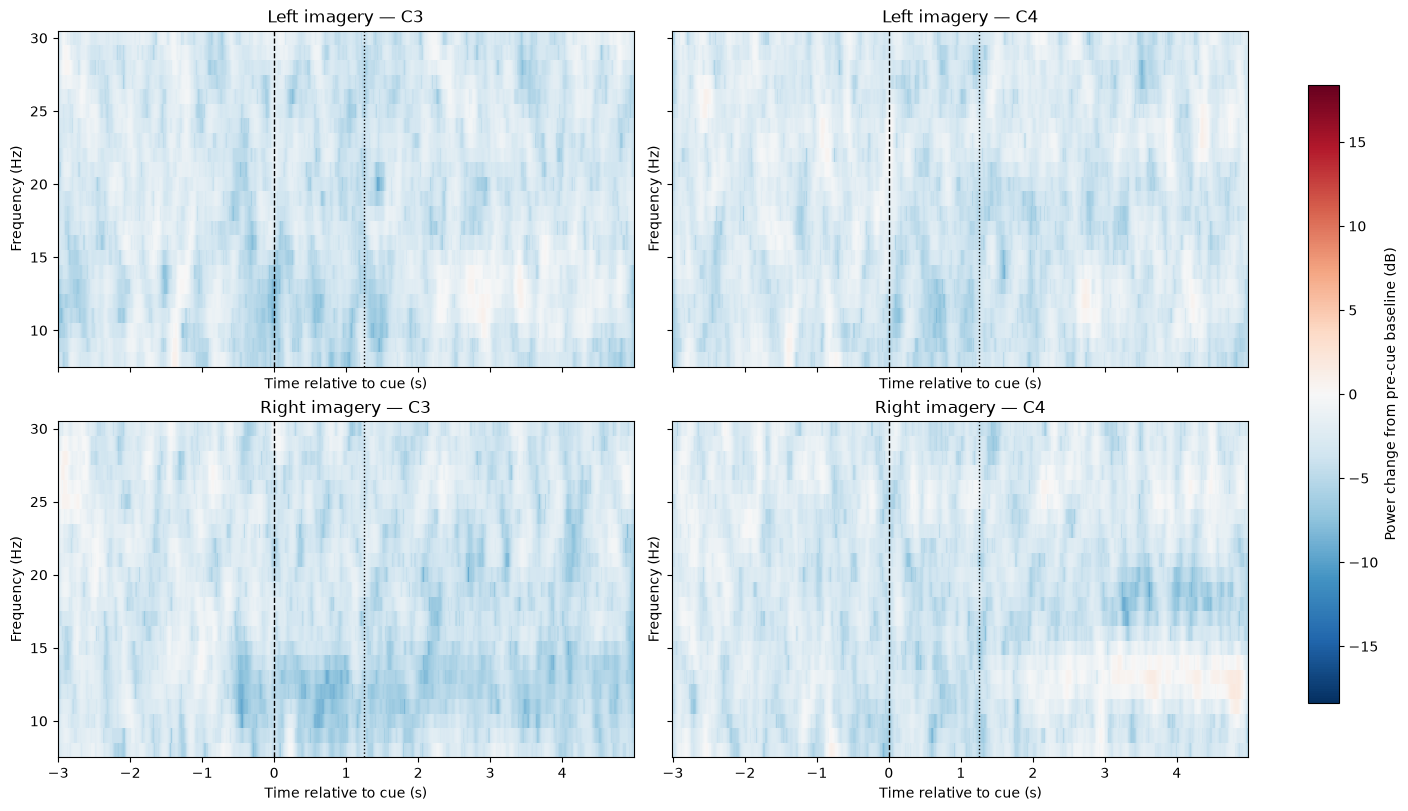

In [6]:
plot_channels = ['C3', 'C4']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True, constrained_layout=True)
limit = np.nanpercentile(np.abs(ersp_db[:, [eeg_channels.index(c) for c in plot_channels]]), 98)

for row_index, class_label in enumerate(['left', 'right']):
    class_mask = class_labels == class_label
    for column_index, channel in enumerate(plot_channels):
        channel_index = eeg_channels.index(channel)
        class_average = ersp_db[class_mask, channel_index].mean(axis=0)
        axis = axes[row_index, column_index]
        image = axis.pcolormesh(
            tfr_times, frequencies_hz, class_average,
            shading='auto', cmap='RdBu_r', vmin=-limit, vmax=limit,
        )
        axis.axvline(0, color='black', linestyle='--', linewidth=1, label='cue')
        axis.axvline(1.25, color='black', linestyle=':', linewidth=1, label='feedback')
        axis.set_title(f'{class_label.capitalize()} imagery — {channel}')
        axis.set_ylabel('Frequency (Hz)')
        axis.set_xlabel('Time relative to cue (s)')

fig.colorbar(image, ax=axes, label='Power change from pre-cue baseline (dB)', shrink=0.85)
plt.show()

## Save a neural-network-ready tensor

The saved tensor is `trials × electrodes × frequencies × time`. Labels are 0 for left and 1 for right. Float32 is used to keep the file practical without reducing the source EEG precision during preprocessing.

In [8]:
tensor_path = OUTPUT_ROOT / 'A10_R3_trial_ersp_8_30Hz.npz'
temporary_path = tensor_path.with_name(tensor_path.name + '.tmp.npz')
np.savez_compressed(
    temporary_path,
    X=ersp_db.astype(np.float32),
    y=class_ids.astype(np.int8),
    class_names=np.asarray(['left', 'right']),
    channels=np.asarray(eeg_channels),
    frequencies_hz=frequencies_hz,
    times_relative_to_cue_seconds=tfr_times,
    trial_numbers=trial_df['trial'].to_numpy(),
    source_file=np.asarray(GDF_PATH.name),
    baseline_seconds_relative_to_cue=np.asarray([-3.0, -1.0]),
)
temporary_path.replace(tensor_path)

print(f'Saved: {tensor_path}')
print(f'X shape: {ersp_db.shape}; y distribution: {dict(zip(*np.unique(class_labels, return_counts=True)))}')

Saved: /Users/aninanni/Documents/cosmos/26-the-data-miners-analysis/bci_cleaning/data/processed/trial_time_frequency/A10/A10_R3_trial_ersp_8_30Hz.npz
X shape: (40, 27, 23, 512); y distribution: {'left': np.int64(20), 'right': np.int64(20)}


## Important limitations

- Morlet estimates near the beginning and end of an epoch contain edge effects. A production pipeline can transform padded intervals and crop back to the exact trial.
- The left/right visual cue occurs at 0 seconds, and online feedback begins at +1.25 seconds. A classifier can therefore learn visual or feedback-related activity instead of motor imagery. Results should be compared across pre-feedback and feedback periods.
- This single recording is a pipeline demonstration, not sufficient training data. The same event-defined transformation should be applied to eligible participants, with train/validation/test splits grouped by participant.
- Automated artifact rejection has not yet been applied at the trial level. EOG/EMG sensors are excluded as inputs, but their signals should later be used to detect contaminated EEG trials.